In [6]:
# Generar los puntos
import numpy as np
from matplotlib import pyplot as plt
from sklearn.svm import SVC

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([0, 1, 1, 0])

# Plot them and color them


In [11]:
# Test out SVM with poly kernel
from sklearn import svm
model = svm.SVC(kernel="poly", degree=2, coef0=0)
model.fit(X, y)
model.score(X, y)

1.0

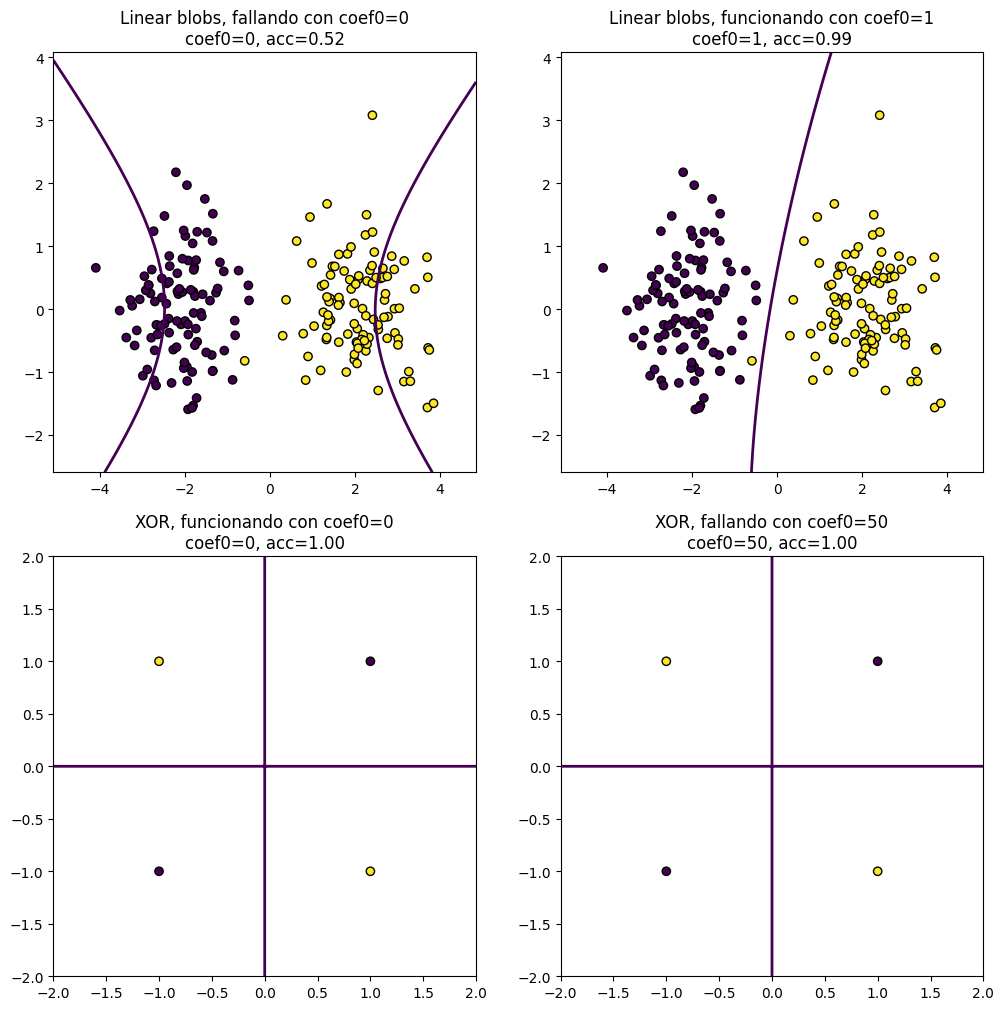

In [28]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# Fix random seed
np.random.seed(42)

# 1. Linearly separable dataset (Gaussian blobs)
X1, y1 = make_blobs(n_samples=200, centers=[(-2, 0), (2, 0)], cluster_std=0.8)

# 2. XOR dataset
X2 = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y2 = np.array([0, 1, 1, 0])

# Helper to train and plot
def plot_svm(X, y, degree, gamma, coef0, title, ax):
    clf = svm.SVC(kernel='poly', degree=degree, gamma=gamma, coef0=coef0)
    clf.fit(X, y)
    acc = clf.score(X, y)

    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=[0], linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    ax.title.set_text(f"{title}\ncoef0={coef0}, acc={acc:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Case A: Linear data with degree=2
plot_svm(X1, y1, degree=2, gamma=1, coef0=0, title='Linear blobs, fallando con coef0=0', ax=axes[0, 0])
plot_svm(X1, y1, degree=2, gamma=1, coef0=1, title='Linear blobs, funcionando con coef0=1', ax=axes[0, 1])

# Case B: XOR with degree=2
plot_svm(X2, y2, degree=2, gamma=1, coef0=0, title='XOR, funcionando con coef0=0', ax=axes[1, 0])
plot_svm(X2, y2, degree=2, gamma=1, coef0=50, title='XOR, fallando con coef0=50', ax=axes[1, 1])

plt.show()